# Class agreement across runs

For each entry in `RUNS` (a run output folder + one of its checkpoints), read the yaml that `scripts/class_agreement_sweep.py` wrote into `<run dir>/class_agreement/`, and plot how often an ImageNet classifier gives the generated image the same top-1 class as the original val image whose conditioning embedding produced it.

One bar per entry, grouped by training dataset (the `dataset` field in `RUNS`); groups and bars keep `RUNS` order. The gray tick on each bar is the shuffled baseline: agreement between generated and *unrelated* originals, i.e. what agreement looks like by chance given how concentrated the predicted labels are. A bar is only meaningful by how far it sits above its tick.

Runs are given by output folder rather than by config file, since several runs can share one config. To produce the yaml files, run on the server, per run:

```bash
python -m scripts.class_agreement_sweep --run_dir outputs/<run>                      # latest checkpoint
python -m scripts.class_agreement_sweep --run_dir outputs/<run> --ckpts best_ckpt.pt  # or a specific one
```

and copy `<run>/class_agreement/*.yaml` back here. For local use -- no GPU, just reading yaml files and plotting.

In [19]:
import os
import glob

import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker
from matplotlib.patches import Patch

In [20]:
REPO_ROOT = ".."

# One bar per entry, grouped into panels by "dataset". Fields:
#   run_dir  run output folder, relative to REPO_ROOT
#   dataset  training dataset the run belongs to (panel), e.g. "imagenet64" or "stimuli"
#   label    text under the bar
#   ckpt     "latest" (highest-step ckpt_step_* evaluated), "best" (best_ckpt.pt), or a step
#            number, e.g. 200_000. Optional, default "latest".
# The same run_dir can appear more than once, e.g. to compare two of its checkpoints.
RUNS = [
    {"run_dir": "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z50",
     "dataset": "imagenet64", "label": "AlexNet fc6, 50 PCs"},
    {"run_dir": "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z200",
     "dataset": "imagenet64", "label": "AlexNet fc6, 200 PCs"},
    {"run_dir": "outputs/diffusion_full_imagenet64_flow_grad_accum_ema_h64_mc192_ch1x2x3x4_T1000_flow_dinov2_vitb14_z50",
     "dataset": "imagenet64", "label": "DINOv2 ViT-B, 50 PCs"},
    {"run_dir": "outputs/diffusion_full_stimuli_finetune_flow_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z50",
     "dataset": "stimuli", "label": "AlexNet fc6, 50 PCs (finetuned)", "ckpt": "best"},
    {"run_dir": "outputs/diffusion_full_stimuli_finetune_flow_h64_mc192_ch1x2x3x4_T1000_flow_alexnet_fc6_z200",
     "dataset": "stimuli", "label": "AlexNet fc6, 200 PCs (finetuned)", "ckpt": "best"},
]

CLASSIFIER = "resnet50"         # one of the classifiers the sweep was run with
METRIC = "top1_agreement"       # or "top5_agreement"
GUIDANCE_SCALE = 1.0            # picks the <stem>_g{GUIDANCE_SCALE:g}.yaml files

In [21]:
def find_yaml(eval_dir: str, ckpt) -> str:
    """Path of the class-agreement yaml for one checkpoint of a run, or None if not evaluated."""
    g = f"g{GUIDANCE_SCALE:g}"
    if ckpt == "best":
        path = os.path.join(eval_dir, f"best_ckpt_{g}.yaml")
    elif ckpt == "latest":
        # ckpt_step_{step:07d}: lexicographic order is step order
        periodic = sorted(glob.glob(os.path.join(eval_dir, f"ckpt_step_*_{g}.yaml")))
        path = periodic[-1] if periodic else None
    else:
        path = os.path.join(eval_dir, f"ckpt_step_{int(ckpt):07d}_{g}.yaml")
    return path if path and os.path.exists(path) else None


# One row per RUNS entry. An entry whose yaml is missing (or wasn't scored with CLASSIFIER) is
# warned about and dropped, so the other runs can still be plotted.
rows = []
for run in RUNS:
    ckpt = run.get("ckpt", "latest")
    eval_dir = os.path.join(REPO_ROOT, run["run_dir"], "class_agreement")
    path = find_yaml(eval_dir, ckpt)
    if path is None:
        print(f"[{run['label']}] no yaml for ckpt={ckpt!r}, guidance {GUIDANCE_SCALE:g} in {eval_dir} -- skipping")
        continue
    with open(path) as f:
        info = yaml.safe_load(f)
    scores = info["classifiers"].get(CLASSIFIER)
    if scores is None:
        print(f"[{run['label']}] {os.path.basename(path)} has no {CLASSIFIER!r} scores "
              f"(has {list(info['classifiers'])}) -- skipping")
        continue
    if info["dataset_type"] != run["dataset"]:
        print(f"[{run['label']}] WARNING: RUNS says dataset {run['dataset']!r}, "
              f"but the run was trained on {info['dataset_type']!r}")
    rows.append({
        "label": run["label"],
        "dataset": run["dataset"],
        "ckpt": os.path.basename(info["checkpoint"]),
        "step": info["step"],
        "value": scores[METRIC],
        "baseline": scores["shuffled_top1_agreement"],
        "n_images": info["n_images"],
    })

assert rows, "Nothing to plot -- run scripts/class_agreement_sweep.py for at least one RUNS entry first."

for r in rows:
    print(f"{r['dataset']:>10} | {r['label']:<32} {r['ckpt']:<22} step {r['step']:>8,}   "
          f"{METRIC} {100 * r['value']:5.1f}%   shuffled {100 * r['baseline']:5.1f}%   (n={r['n_images']})")

imagenet64 | AlexNet fc6, 50 PCs              ckpt_step_0300000.pt   step  300,000   top1_agreement  22.9%   shuffled   0.5%   (n=1000)
imagenet64 | AlexNet fc6, 200 PCs             ckpt_step_0250000.pt   step  250,000   top1_agreement   0.5%   shuffled   0.2%   (n=1000)
imagenet64 | DINOv2 ViT-B, 50 PCs             ckpt_step_0050000.pt   step   50,000   top1_agreement  26.7%   shuffled   0.2%   (n=1000)
   stimuli | AlexNet fc6, 50 PCs (finetuned)  best_ckpt.pt           step      600   top1_agreement  20.8%   shuffled   2.0%   (n=500)
   stimuli | AlexNet fc6, 200 PCs (finetuned) best_ckpt.pt           step      400   top1_agreement  19.6%   shuffled   2.0%   (n=500)


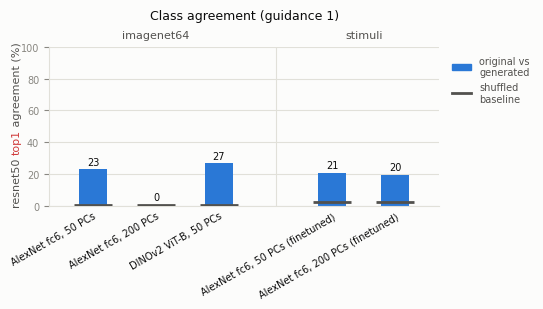

In [22]:
# Chart tokens: one series -> one hue; neutral inks.
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
HIGHLIGHT = "#d03b3b"   # red: which metric (top1 / top5) the y axis shows
BAR_COLOR = "#2a78d6"
BAR_W, GROUP_GAP = 0.45, 0.8

# Bars laid out left to right, grouped by dataset (groups and bars within a group in RUNS order).
datasets = list(dict.fromkeys(r["dataset"] for r in rows))
xs, plotted, group_spans, x = [], [], [], 0.0
for dataset in datasets:
    start = x
    for r in (r for r in rows if r["dataset"] == dataset):
        xs.append(x)
        plotted.append(r)
        x += 1
    group_spans.append((dataset, start, x - 1))
    x += GROUP_GAP

fig, ax = plt.subplots(figsize=(0.55 * len(plotted) + GROUP_GAP * len(datasets) + 1.2, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for x, r in zip(xs, plotted):
    ax.bar(x, 100 * r["value"], width=BAR_W, color=BAR_COLOR, zorder=2)
    ax.hlines(100 * r["baseline"], x - BAR_W / 2 - 0.08, x + BAR_W / 2 + 0.08, color=INK_2, linewidth=2, zorder=3)
    ax.text(x, 100 * r["value"] + 1.5, f"{100 * r['value']:.0f}", ha="center", va="bottom", fontsize=7, color=INK)

# Dataset name above each group, thin separators between groups.
for i, (dataset, start, end) in enumerate(group_spans):
    ax.text((start + end) / 2, 1.04, dataset, transform=ax.get_xaxis_transform(),  # above the plot area
            ha="center", va="bottom", fontsize=8, color=INK_2)
    if i:
        ax.axvline(start - (1 + GROUP_GAP) / 2, color=GRID, linewidth=0.8, zorder=0)

ax.set_xticks(xs, [r["label"] for r in plotted], rotation=30, ha="right", rotation_mode="anchor", fontsize=7, color=INK)
ax.set_xlim(xs[0] - 0.7, xs[-1] + 0.7)
ax.set_ylim(0, 100)
# y label with the metric (top1 / top5) in red: rotated text pieces stacked bottom to top
metric_kind, metric_rest = METRIC.split("_", 1)
ylabel_parts = [(f"{CLASSIFIER} ", INK_2), (metric_kind, HIGHLIGHT), (f" {metric_rest} (%)", INK_2)]
ylabel = VPacker(
    children=[TextArea(text, textprops=dict(color=color, fontsize=8, rotation=90, va="bottom"))
              for text, color in reversed(ylabel_parts)],
    align="center", pad=0, sep=0,
)
ax.add_artist(AnchoredOffsetbox(loc="center right", child=ylabel, bbox_to_anchor=(-0.07, 0.5),
                                bbox_transform=ax.transAxes, frameon=False, borderpad=0, pad=0))
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
ax.tick_params(axis="y", colors=MUTED, labelsize=7)
ax.tick_params(axis="x", length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)

# Legend stacked vertically to the right of the plot instead of a row across the top.
ax.legend(
    handles=[Patch(color=BAR_COLOR, label="original vs\ngenerated"),
             Line2D([], [], color=INK_2, linewidth=2, label="shuffled\nbaseline")],
    loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=7, labelcolor=INK_2,
)
ax.set_title(f"Class agreement (guidance {GUIDANCE_SCALE:g})", loc="center", fontsize=9, color=INK, pad=20)
fig.tight_layout()
plt.savefig("top1_class_agreement.png")
plt.show()